In [10]:
import sys
sys.path.append("../")

from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from aqua.plotting_functions import *
from aqua.utils import *
from aqua.batchAQUA_general import batchAQUA

from functions import *

In [11]:
# strong autaptic neuron on RS resonator...
E1_neuron = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 150., 'tau': 0.} # strong autaptic neuron on RS resonator...

T = 150
dt = 0.1
defaultclock.dt = dt*ms
N_iter = int(T/dt)

# initial conditions
x_start = np.array([[-60., 0., 0.]])
t_start = np.array([[0.]])

E1 = batchAQUA([E1_neuron])
E1.Initialise(x_start, t_start)

# stimulus
I = 75 * np.ones((1, N_iter))
I_TA = TimedArray(values = I.T, dt = dt*ms, name = 'I_TA')


autapse_charge = E1.get_net_autapse_currents()
print(f"NET CHARGE: {autapse_charge}")

# time constants for non-standard autapses
t_a1_biexp = 1                      # rise time  [ms]
t_a2_biexp = 1/E1_neuron['e']       # decay time [ms]

t_a1_uniform = E1_neuron['tau']     # delay of the uniform pulse [ms]
t_a2_uniform = 50                   # end of the pulse [ms]

# peak currents for non-standard autapses
I_peak_biexp = convert_to_biexponential_peak(autapse_charge, t_a1_biexp, t_a2_biexp)
I_peak_uniform = autapse_charge / (t_a2_uniform - t_a1_uniform)

''' Convert the neuron to brian2 objects '''

E1_standard, aut_standard = E1.meetBrian(stimulus_name = I_TA)    # should create a standard autapse

E1_biexp, aut_biexp = E1.meetBrian(stimulus_name = I_TA, autapse_type = 'biexponential', 
                                   t_a1 = t_a1_biexp, t_a2 = t_a2_biexp, I_peak = I_peak_biexp)    # should create a standard autapse

E1_uniform, aut_uniform = E1.meetBrian(stimulus_name = I_TA, autapse_type = 'uniform', 
                                   t_a1 = t_a1_uniform, t_a2 = t_a2_uniform, I_peak = I_peak_uniform)    # should create a standard autapse


# create monitor for each neuron's autapes

mon_std = StateMonitor(E1_standard, ['v', 'w'], record = True)
mon_biexp = StateMonitor(E1_biexp, ['v', 'w'], record = True)
mon_uni = StateMonitor(E1_uniform, ['v', 'w'], record = True)

run(T*ms)


NET CHARGE: [750.]
NO SYNAPSE EQUATION (t_syn = 5)
NO SYNAPSE EQUATION (t_syn = 5)
NO SYNAPSE EQUATION (t_syn = 5)


Text(0.5, 1.0, 'uniform autapse')

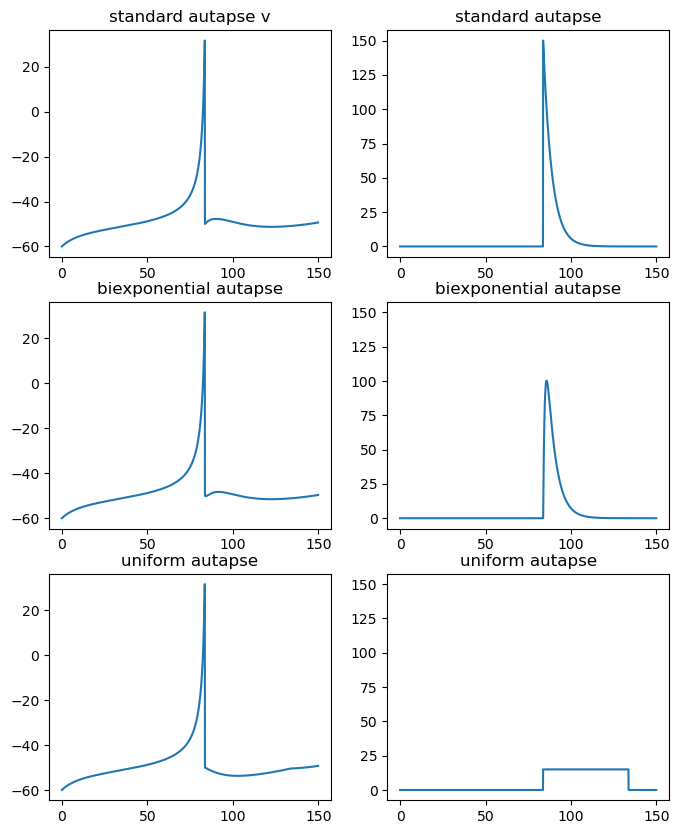

In [13]:
fig, ax = plt.subplots(3, 2, figsize = (8, 10), sharey = 'col')

ax[0, 0].plot(mon_std.t/ms, mon_std.v[0])
ax[0, 0].set_title('standard autapse v')
ax[0, 1].plot(mon_std.t/ms, mon_std.w[0])
ax[0, 1].set_title('standard autapse')

ax[1, 0].plot(mon_biexp.t/ms, mon_biexp.v[0])
ax[1, 0].set_title('biexponential autapse')
ax[1, 1].plot(mon_biexp.t/ms, mon_biexp.w[0])
ax[1, 1].set_title('biexponential autapse')

ax[2, 0].plot(mon_uni.t/ms, mon_uni.v[0])
ax[2, 0].set_title('uniform autapse')
ax[2, 1].plot(mon_uni.t/ms, mon_uni.w[0])
ax[2, 1].set_title('uniform autapse')

